# Is the IC result robust across alternate histories, not just across dates?

`scorer_comparison.ipynb` found every scorer's mean IC statistically
indistinguishable from zero using `evaluation.ic_significance` -- but
that test only uses date-to-date variation WITHIN the one real price
history we have (~40-50 rebalance dates). This notebook uses the
`src2/bootstrap/data_gen.py` engine to generate many
synthetic-but-realistic alternate histories (same dates/tickers,
block-resampled returns/volume) and asks the same question with many
more independent samples: across worlds, not just across dates.

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd

from src2 import vector_calc, iteration, evaluation, data_ingest, bootstrap


## 1. Data (same universe as scorer_comparison.ipynb)

In [ ]:
tickers = 'ALGN,AAPL,PANW,AMD,ZS,MDLZ,XEL,VRSN,INSM,ON,WDAY,ENPH,DLTR,ADI,COST,ABNB,CEG,MSFT,GOOGL,CDNS,PYPL,FAST,JD,MTCH,SNPS,LULU,CMCSA,ADBE,ADSK'.split(',')

tickers=tickers+['SPY','QQQ']

broker = data_ingest.DataBroker(tickers=tickers, start_date="2022-01-01", end_date="2026-04-01")
universe_data = broker.fetch_universe_data()

rebalance_dates = iteration.generate_rebalance_dates(universe_data['price'], interval="ME")


In [ ]:
# benchmark_ticker=['SPY','QQQ']
# bench_broker = data_ingest.DataBroker(tickers=['SPY', 'QQQ'], start_date="2022-01-01", end_date="2026-04-01")
# bench_price = bench_broker.fetch_universe_data()['price']


## 2. Generate synthetic worlds via stationary bootstrap

In [ ]:
NUM_SIMULATIONS = 1000

engine = bootstrap.data_gen.VectorizedBootstrapEngine(universe_data, expected_block_size=21)
bootstrap_result = engine.generate_all_worlds(num_simulations=NUM_SIMULATIONS)

bootstrap_result['price_tensor'].shape


Note: the bootstrap engine trims one day computing `pct_change()`, so
`dates_index`/`tickers` must come from the engine itself, not the raw
`universe_data`, to stay aligned with the tensor shapes.

In [103]:
dates_index = engine.dates_index
eng_tickers = engine.tickers
eng_rebalance_dates = [d for d in rebalance_dates if d in set(dates_index)]
len(dates_index), len(eng_rebalance_dates)

(1063, 51)

## 3. Bootstrap IC distribution per scorer

In [ ]:
SCORER_CONFIGS = {
    # "mean_reversion_40d": dict(score_fn=vector_calc.rolling_mean_reversion_score, window=40),
    # "mean_reversion_60d": dict(score_fn=vector_calc.rolling_mean_reversion_score, window=60),
    "geometric_drift_126d": dict(score_fn=vector_calc.rolling_geometric_drift_score, window=126),
    "geometric_drift_252d": dict(score_fn=vector_calc.rolling_geometric_drift_score, window=252),
}


## 4. Run every scorer on every bootstrap world, collect `evaluation.calculate_metrics`

For each of the `NUM_SIMULATIONS` synthetic worlds: build the synthetic
`{'price', 'volume'}` universe, run every scorer config through the same
`vector_calc` -> `iteration` pipeline as `scorer_comparison.ipynb`,
assemble a `df_nav_all` (benchmark + each scorer's NAV), and run
`evaluation.calculate_metrics(df_nav_all)` on it -- exactly like section 4 of
`scorer_comparison.ipynb`, just repeated across worlds. The benchmark
(SPY/QQQ) is real data, reindexed onto the synthetic dates_index -- it's
the same every simulation, giving a fixed reference point per world.

In [105]:
from importlib import reload

In [ ]:
reload(bootstrap.simulation)


In [ ]:
import os
from concurrent.futures import ProcessPoolExecutor, as_completed

bench_tickers = ['SPY', 'QQQ']
WARMUP_DAYS = 252  # longest scorer lookback (geometric_drift_252d) -- drop this much NAV before scoring

price_tensor = bootstrap_result['price_tensor']
volume_tensor = bootstrap_result['volume_tensor']

bootstrap_metrics_rows = []
n_workers = os.cpu_count()
with ProcessPoolExecutor(max_workers=n_workers) as pool:
    futures = {
        pool.submit(
            bootstrap.simulation.run_one_simulation,
            sim_id,
            price_tensor[sim_id],
            volume_tensor[sim_id],
            dates_index,
            eng_tickers,
            eng_rebalance_dates,
            SCORER_CONFIGS,
            bench_tickers,
            0.25,
            "equal",
            WARMUP_DAYS,
        ): sim_id
        for sim_id in range(NUM_SIMULATIONS)
    }

    done = 0
    for future in as_completed(futures):
        bootstrap_metrics_rows.append(future.result())
        done += 1
        if done % 20 == 0:
            print(f"{done}/{NUM_SIMULATIONS} simulations done")


In [117]:
bootstrap_metrics = pd.concat(bootstrap_metrics_rows, ignore_index=True)
bootstrap_metrics.shape

(4000, 7)

We don't collect `df_nav` for all `NUM_SIMULATIONS` worlds (returning a
full NAV series per scorer per world from every `ProcessPoolExecutor`
call would multiply the amount of data pickled back to the main process
by ~`len(dates_index)`, for no benefit to the aggregate stats above) --
but `bootstrap.simulation.build_world_nav` is the same NAV-building code
`run_one_simulation` uses internally, exposed standalone. Call it for a
single `sim_id`, single-process, to get a `df_nav_all` in the exact shape
`evaluation.plot_rebased_performance` from `scorer_comparison.ipynb` expects.

In [ ]:
# evaluation.plot_rebased_performance is already imported above -- no extra import needed here


In [ ]:
peek_sim_id = 0

df_nav_peek = bootstrap.simulation.build_world_nav(
    peek_sim_id,
    price_tensor[peek_sim_id],
    volume_tensor[peek_sim_id],
    dates_index,
    eng_tickers,
    eng_rebalance_dates,
    SCORER_CONFIGS,
    bench_tickers,
)

evaluation.plot_rebased_performance(df_nav_peek)


In [119]:
bootstrap_metrics.head()

,sim_id,scorer,CAGR,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Calmar_Ratio
0,3,SPY,0.232177,1.563939,2.528210,0.222896,1.041637
1,3,QQQ,0.313407,1.617720,2.682598,0.247911,1.264191
2,3,geometric_drift_126d,0.184947,0.966220,1.601388,0.316675,0.584028
3,3,geometric_drift_252d,0.275843,1.338982,2.282205,0.231559,1.191243
4,7,SPY,0.234604,1.524357,2.662488,0.218086,1.075741


## 5. Distribution of each metric across worlds, per scorer

In [118]:
bootstrap_metrics.groupby("scorer").agg(["mean", "std"])

sim_id                  CAGR           Sharpe_Ratio  \
                       mean         std      mean       std         mean   
scorer                                                                     
QQQ                   499.5  288.819436  0.107305  0.128902     0.661985   
SPY                   499.5  288.819436  0.096872  0.093331     0.746493   
geometric_drift_126d  499.5  288.819436  0.108114  0.142221     0.595924   
geometric_drift_252d  499.5  288.819436  0.149554  0.149437     0.784838   

                               Sortino_Ratio           Max_Drawdown            \
                           std          mean       std         mean       std   
scorer                                                                          
QQQ                   0.627144      1.122375  1.070083     0.312286  0.100905   
SPY                   0.617096      1.258681  1.053990     0.234571  0.077408   
geometric_drift_126d  0.600466      1.047376  1.063017     0.322323  0.091253   
geometric_drift_252d  0.621405      1.378025  1.118423     0.293164  0.083753   

                     Calmar_Ratio            
                             mean       std  
scorer                                       
QQQ                      0.489955  0.607868  
SPY                      0.560993  0.603252  
geometric_drift_126d     0.454448  0.603495  
geometric_drift_252d     0.657652  0.740024

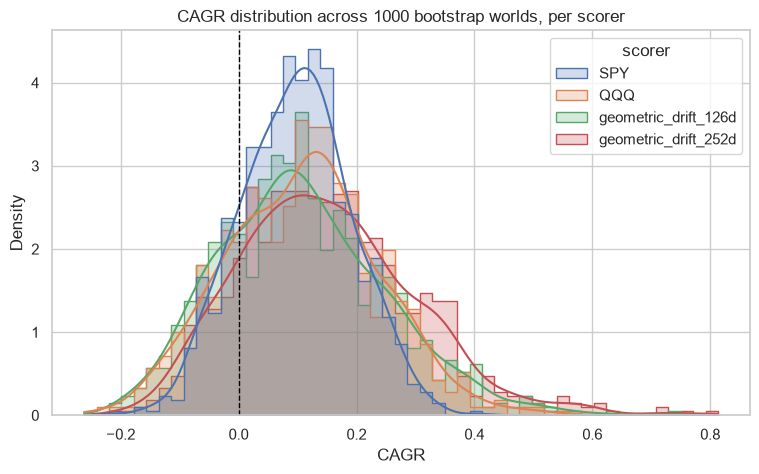

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=bootstrap_metrics, x="CAGR", hue="scorer",
    stat="density", common_norm=False, kde=True,
    element="step", alpha=0.25, ax=ax,
)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_title(f"CAGR distribution across {NUM_SIMULATIONS} bootstrap worlds, per scorer")
plt.show()

In [84]:
# bootstrap_metrics

## 6. Is each scorer significantly different from the benchmarks?

`sim_id` pairs every scorer with SPY/QQQ on the SAME synthetic world, so
this is a paired-samples question, not independent-samples -- an unpaired
test would throw away that pairing and understate power. `src2.bootstrap.significance`
(built on the paired-test helpers in `src2/evaluation/significance_test.py`)
reports, per scorer x benchmark x metric:

- `win_rate` / `ci_2.5`-`ci_97.5`: assumption-free -- fraction of worlds
  the scorer beat the benchmark in, and the empirical 95% CI of the
  per-world difference. This is the number to lead with.
- `p_value` / `significant_at_5pct`: `evaluation.automated_paired_test`
  picks a paired t-test or Wilcoxon signed-rank test per Shapiro
  normality check on the differences, as a formal cross-check.

In [ ]:
scorer_names = list(SCORER_CONFIGS.keys())

sig_results = bootstrap.significance.compare_all(
    bootstrap_metrics,
    scorers=scorer_names,
    benches=bench_tickers,
)


In [125]:
sig_results.columns

Index(['scorer', 'bench', 'metric', 'n_sims', 'mean_diff', 'median_diff',
       'win_rate', 'ci_2.5', 'ci_97.5', 'test_name', 'statistic', 'p_value',
       'significant_at_5pct'],
      dtype='str')

In [126]:
sig_results[sig_results["metric"] == "CAGR"][
    ["scorer", "bench", "win_rate", "mean_diff", "ci_2.5", "ci_97.5", "test_name", "p_value", "significant_at_5pct"]
].sort_values(["scorer", "bench"])

,scorer,bench,win_rate,mean_diff,ci_2.5,ci_97.5,test_name,p_value,significant_at_5pct
5,geometric_drift_126d,QQQ,0.474,0.000809,-0.176380,0.197868,Wilcoxon Signed-Rank Test,5.614439e-01,False
0,geometric_drift_126d,SPY,0.499,0.011242,-0.152495,0.224213,Wilcoxon Signed-Rank Test,4.407864e-02,True
15,geometric_drift_252d,QQQ,0.658,0.042249,-0.146541,0.249180,Wilcoxon Signed-Rank Test,2.260664e-33,True
10,geometric_drift_252d,SPY,0.678,0.052682,-0.122967,0.272080,Wilcoxon Signed-Rank Test,4.515264e-47,True


In [ ]:
bootstrap.significance.compare_scorer_vs_benchmark(bootstrap_metrics, 'QQQ', 'SPY', 'CAGR')


### 6b. One-sided: did the scorer beat the benchmark? (not just "differ from it")

`compare_scorer_vs_benchmark_one_sided` / `compare_all_one_sided` test
H1: scorer > bench directly (`alternative="greater"`), which is what
"does this scorer actually beat SPY/QQQ" really is -- a one-sided test
has more power for that directional question than the two-sided test in
section 6, at the same significance threshold.

In [ ]:
reload(bootstrap.significance)


In [ ]:
sig_results_one_sided = bootstrap.significance.compare_all_one_sided(
    bootstrap_metrics,
    scorers=scorer_names,
    benches=bench_tickers,
    alternative="greater",
)

sig_results_one_sided[sig_results_one_sided["metric"] == "CAGR"][
    ["scorer", "bench", "win_rate", "mean_diff", "test_name", "p_value", "significant_at_5pct"]
].sort_values(["scorer", "bench"])


In [ ]:
bootstrap.significance.compare_scorer_vs_benchmark(bootstrap_metrics, 'QQQ', 'SPY', 'CAGR')


In [ ]:
wide = bootstrap_metrics.pivot(index="sim_id", columns="scorer", values='CAGR')
scorer='QQQ'
bench='SPY'
evaluation.automated_paired_test_one_sided(wide[scorer], wide[bench], alternative='greater')


## 7. Conditional performance: does each scorer's edge depend on the market regime?

Sections 6/6b pool all worlds into one win-rate/p-value. That averages away
the more useful question: a mean-reversion scorer that wins in choppy
markets and loses in trending ones could pool to a mediocre-looking
average despite having a real, strong conditional edge. Classify each
world's regime from its benchmark's raw price path (no backtest needed --
see notes/stationary_bootstrap.md section 5 for why R² of a log-price
trend fit, not just net return), then rerun the paired comparison *within*
each regime.

Two passes, since "bull/bear" is only meaningful relative to the spread of
outcomes across all worlds:
1. `classify_world_regime` per sim_id -- cheap (just an OLS fit), plain loop.
2. `label_regimes` buckets by tercile of total_return (direction) and R²
   threshold (trending vs. choppy) across the whole population at once.

In [ ]:
reload(bootstrap.data_gen)

REGIME_TICKER = 'SPY'

trend_features = pd.DataFrame([
    bootstrap.data_gen.classify_world_regime(
        sim_id, price_tensor[sim_id], dates_index, eng_tickers,
        regime_ticker=REGIME_TICKER, warmup_days=WARMUP_DAYS,
    )
    for sim_id in range(NUM_SIMULATIONS)
])

world_regimes = bootstrap.data_gen.label_regimes(trend_features)
world_regimes['regime'].value_counts()


In [ ]:
bootstrap_metrics_regime = bootstrap_metrics.merge(
    world_regimes[['sim_id', 'regime', 'total_return', 'r2']], on='sim_id', how='left'
)

conditional_results = pd.concat([
    bootstrap.significance.compare_all(
        bootstrap_metrics_regime[bootstrap_metrics_regime['regime'] == regime],
        scorers=scorer_names,
        benches=bench_tickers,
        metrics=['CAGR'],
    ).assign(regime=regime)
    for regime in world_regimes['regime'].unique()
], ignore_index=True)

conditional_results[
    ['regime', 'scorer', 'bench', 'n_sims', 'win_rate', 'mean_diff', 'p_value', 'significant_at_5pct']
].sort_values(['scorer', 'bench', 'regime'])

In [183]:
scorer_names_check=['geometric_drift_252d','QQQ','SPY']

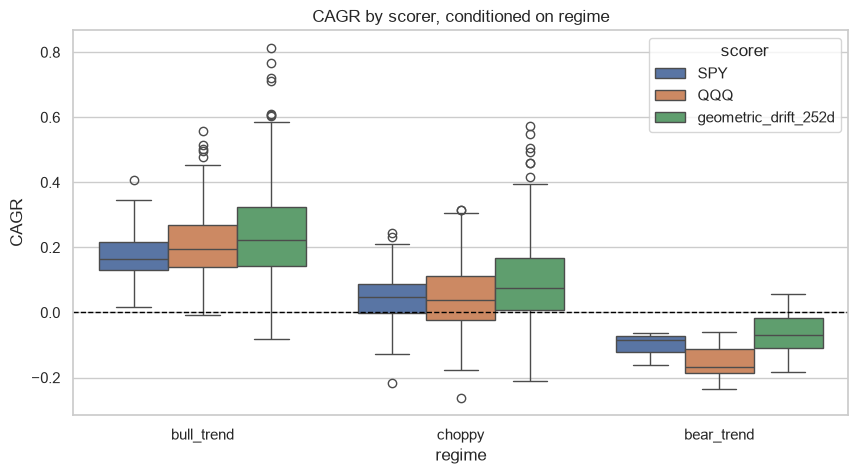

In [184]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=bootstrap_metrics_regime[bootstrap_metrics_regime['scorer'].isin(scorer_names_check)],
    x='regime', y='CAGR', hue='scorer', ax=ax,
)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('CAGR by scorer, conditioned on regime')
plt.show()

In [185]:
conditional_results.columns

Index(['scorer', 'bench', 'metric', 'n_sims', 'mean_diff', 'median_diff',
       'win_rate', 'ci_2.5', 'ci_97.5', 'test_name', 'statistic', 'p_value',
       'significant_at_5pct', 'regime'],
      dtype='str')

In [186]:
conditional_results.loc[conditional_results['regime']=='choppy',['scorer','bench','significant_at_5pct','mean_diff','median_diff','win_rate']]

,scorer,bench,significant_at_5pct,mean_diff,median_diff,win_rate
0,geometric_drift_126d,SPY,False,0.010996,-0.001210,0.498221
1,geometric_drift_126d,QQQ,True,0.015067,0.006844,0.537367
2,geometric_drift_252d,SPY,True,0.044022,0.034112,0.665480
3,geometric_drift_252d,QQQ,True,0.048093,0.040100,0.688612


In [187]:
conditional_results.loc[conditional_results['regime']=='bull_trend',['scorer','bench','significant_at_5pct','mean_diff','median_diff','win_rate']]

,scorer,bench,significant_at_5pct,mean_diff,median_diff,win_rate
4,geometric_drift_126d,SPY,False,0.012225,0.001766,0.505938
5,geometric_drift_126d,QQQ,True,-0.020210,-0.025772,0.377672
6,geometric_drift_252d,SPY,True,0.064989,0.055291,0.700713
7,geometric_drift_252d,QQQ,True,0.032554,0.025051,0.608076


`world_regimes` already carries `sim_id` alongside `regime` (it flows
straight through from `classify_world_regime`'s dict), so
`world_regimes[world_regimes['regime'] == 'choppy']['sim_id']` works
directly -- `bootstrap.data_gen.sample_sim_ids_per_regime` just wraps that
filter and, by default, picks the most extreme example of each regime
(highest total_return for bull_trend, lowest for bear_trend, lowest r2 for
choppy) rather than a borderline case near a tercile/R² cutoff.

In [ ]:
example_sim_ids = bootstrap.data_gen.sample_sim_ids_per_regime(world_regimes,n_per_regime=10)
example_sim_ids


In [ ]:
# for regime, sim_ids in example_sim_ids.items():
regime='choppy'
sim_ids=example_sim_ids[regime]
peek_sim_id = sim_ids[4]
df_nav_peek = bootstrap.simulation.build_world_nav(
    peek_sim_id,
    price_tensor[peek_sim_id],
    volume_tensor[peek_sim_id],
    dates_index,
    eng_tickers,
    eng_rebalance_dates,
    SCORER_CONFIGS,
    bench_tickers,
    warmup_days=WARMUP_DAYS
)
print(f"regime={regime}  sim_id={peek_sim_id}")
evaluation.plot_rebased_performance(df_nav_peek)
